<a href="https://colab.research.google.com/github/abhiahire91/Customer_churn_prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODEL PERFORMANCE
Accuracy: 0.8390
ROC AUC Score: 0.8635

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.59      0.66      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



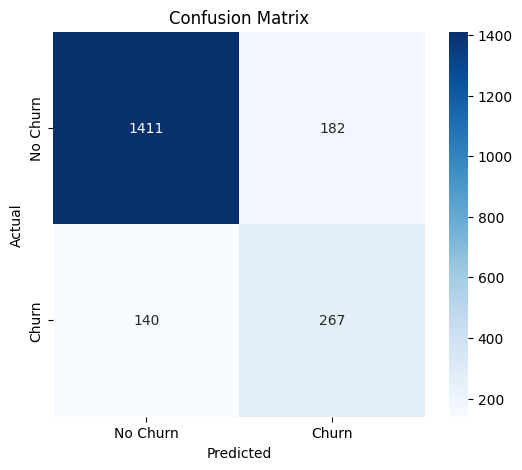

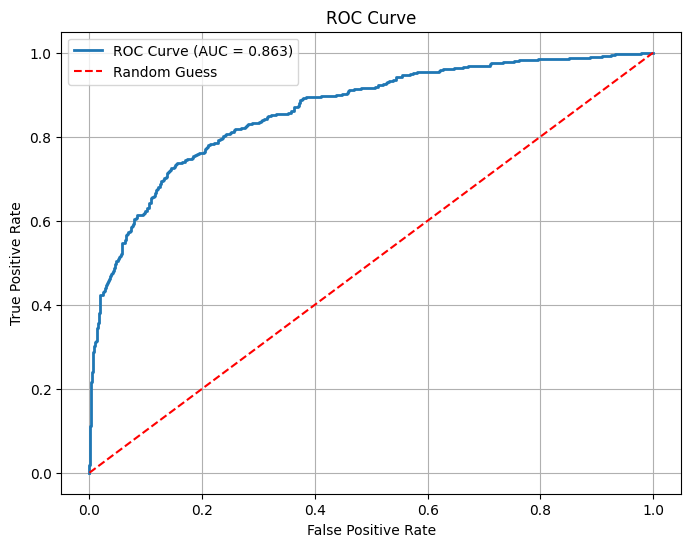

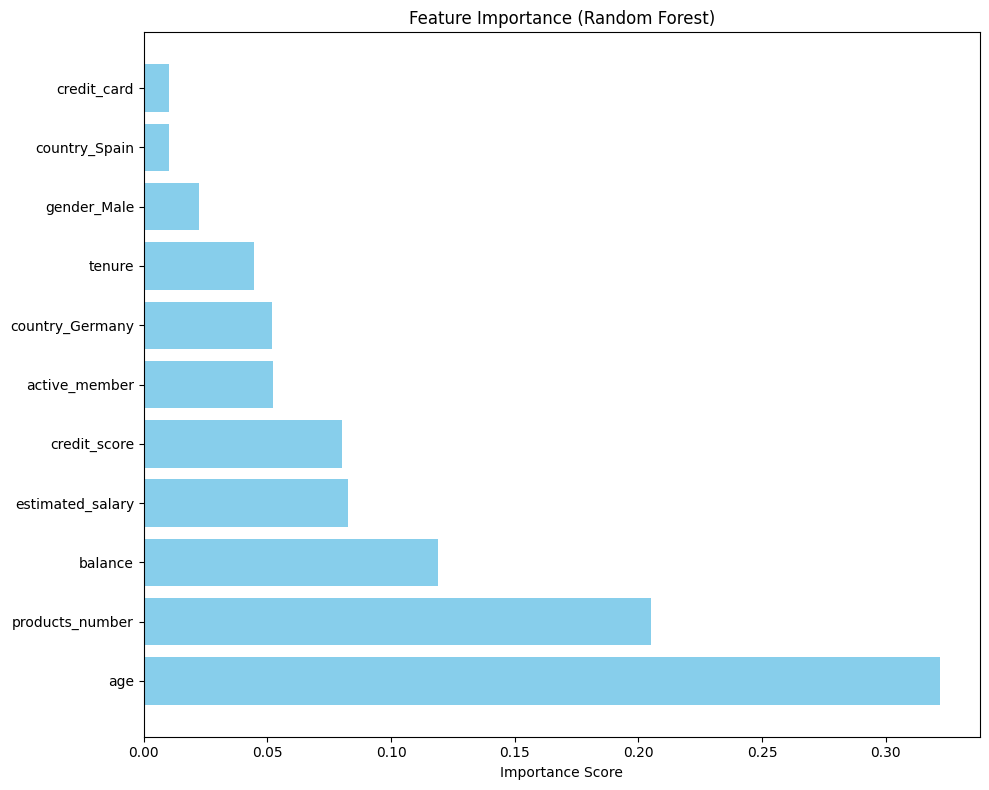


Top 10 Important Features:
age: 0.3221
products_number: 0.2053
balance: 0.1189
estimated_salary: 0.0827
credit_score: 0.0801
active_member: 0.0522
country_Germany: 0.0518
tenure: 0.0445
gender_Male: 0.0222
country_Spain: 0.0102


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                           roc_curve, auc, roc_auc_score)


df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')


if 'customer_id' in df.columns:
    df.drop(columns=['customer_id'], inplace=True)

df['churn'] = df['churn'].astype(int)


df = pd.get_dummies(df, columns=['gender', 'country'], drop_first=True)

X = df.drop(columns=['churn'])
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)


numerical_cols = ['credit_score', 'age', 'tenure', 'balance',
                 'products_number', 'estimated_salary']

scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])


model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]


print("MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


importances = model.feature_importances_
feature_names = X.columns


indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(len(importances)), importances[indices], color='skyblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


print("\nTop 10 Important Features:")
for i in range(min(10, len(feature_names))):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")